# Chapter 2 · Section 2.3
# A Model with Demography

**Source:** Li, M.Y. (2018), pp. 52–60.

Adding demography (equal birth/death rate $b$, total population normalized to 1) to the
Kermack–McKendrick model. This section is the book's first use of **linearization** (Jacobian
eigenvalues), the **Routh–Hurwitz criteria**, **Lyapunov–LaSalle theory**, and the
**Bendixson–Dulac/Poincaré–Bendixson** machinery — all formally developed in Chapter 3, but
introduced here "in the wild" on a concrete example first. We follow the same strategy: use each
tool concretely, verify every claim numerically, and treat the general theory (Ch. 3) as upcoming.


---
## Block 1 (§2.3.1) — The model, and its two equilibria

### 1. Rewrite

With births and deaths both at rate $b$ (population normalized to total size 1) and a non-fatal
disease:
$$S'=b-\beta IS-bS,\qquad I'=\beta IS-\gamma I-bI,\qquad R'=\gamma I-bR \qquad (2.24)$$
Since $S+I+R=1$ is conserved (identical reasoning to before), and neither the $S$ nor $I$ equation
involves $R$, the $(S,I)$-pair forms a self-contained 2D subsystem:
$$S'=b-\beta IS-bS,\qquad I'=\beta IS-\gamma I-bI \qquad (2.25)$$
Setting $S'=I'=0$ and solving the resulting algebraic system gives exactly two equilibria: the
**disease-free equilibrium** $P_0=(1,0)$, and the **endemic equilibrium**
$P^*=(S^*,I^*)=\left(\frac{b+\gamma}{\beta},\ \frac{b[\beta-(b+\gamma)]}{\beta(b+\gamma)}\right)$.
$P^*$ only lies in the biologically meaningful region when $\mathcal{R}_0=\frac{\beta}{b+\gamma}>1$
(otherwise $I^*<0$), and $P^*=P_0$ exactly at $\mathcal{R}_0=1$.

### 2. Simplified

We're adding a "front door" (births) and matching "back doors" (deaths, same size for every room)
to the S/I/R floor plan from before. Because the front door and every back door let exactly the
same *rate* of kids in and out, the *total* number of kids in the school never changes overall —
even though individual kids are constantly arriving and leaving. Just like the plain SIS model,
solving "where does the system stop changing" (setting both room-change-rates to zero) gives two
possible steady pictures: either nobody's sick (disease-free), or a fixed number stay sick forever
as new susceptible kids keep arriving to replace the ones who get infected (endemic).

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $b$ | Common birth AND death rate constant | Keeps $N\equiv1$ exactly, by construction |
| $\mathcal{R}_0=\beta/(b+\gamma)$ | Basic reproduction number for this model | Note: denominator is $b+\gamma$, not just $\gamma$ — demography shortens the effective infectious "window" via added mortality-equivalent removal |
| $P_0=(1,0)$ | Disease-free equilibrium | Always exists |
| $P^*=(S^*,I^*)$ | Endemic equilibrium | Exists (in the feasible region) iff $\mathcal{R}_0>1$ |


In [1]:
# Symbolically solving the equilibrium equations (2.26) to confirm P0 and P*
import sympy as sp

# S, I must be allowed to be exactly 0 (the disease-free case I=0), so we use
# real=True rather than positive=True -- declaring I strictly positive would
# silently discard the I=0 (disease-free) branch of solutions.
S, I = sp.symbols('S I', real=True)
b, beta, gamma = sp.symbols('b beta gamma', positive=True)
eq1 = sp.Eq(b - beta*I*S - b*S, 0)
eq2 = sp.Eq(beta*I*S - gamma*I - b*I, 0)

solutions = sp.solve([eq1, eq2], [S, I], dict=True)
for sol in solutions:
    print({k: sp.simplify(v) for k, v in sol.items()})


{I: 0, S: 1}
{I: b*(-b + beta - gamma)/(beta*(b + gamma)), S: (b + gamma)/beta}


### 10. Verification

SymPy's algebraic solver independently confirms both equilibria match the book's stated
formulas exactly — $P_0=(1,0)$ and $P^*=\left(\frac{b+\gamma}{\beta},
\frac{b(\beta-b-\gamma)}{\beta(b+\gamma)}\right)$ — with no manual algebra required to trust the
result.


---
## Block 2 (§2.3.2) — Local stability via linearization

### 1. Rewrite

**Linearization** approximates a nonlinear system's behavior *near* an equilibrium by its Jacobian
matrix (the matrix of all partial derivatives) evaluated at that point — the eigenvalues of the
Jacobian determine local stability: if every eigenvalue has strictly negative real part, the
equilibrium is locally asymptotically stable; if any eigenvalue has strictly positive real part,
it's unstable.

**At $P_0=(1,0)$:** $J(P_0)=\begin{pmatrix}-b & -\beta\\0 & \beta-(b+\gamma)\end{pmatrix}$. This
matrix is **upper triangular**, so its eigenvalues are just its diagonal entries:
$\lambda_1=-b$ (always negative) and $\lambda_2=\beta-(b+\gamma)$. So $P_0$ is locally
asymptotically stable exactly when $\lambda_2<0 \iff \beta<b+\gamma \iff \mathcal{R}_0<1$, and
unstable (a saddle) when $\mathcal{R}_0>1$. At exactly $\mathcal{R}_0=1$, $\lambda_2=0$ —
linearization is inconclusive here (a "non-hyperbolic" equilibrium), requiring the Lyapunov-function
approach of Block 4.

**At $P^*$:** the Jacobian is not triangular, so eigenvalues aren't immediately readable — instead
the book uses the **Routh–Hurwitz criteria**: for a $2\times2$ matrix, both eigenvalues have
negative real part if and only if $\text{tr}(J)<0$ AND $\det(J)>0$. Direct calculation gives
$\text{tr}(J(P^*))=-b/S^*<0$ always, and $\det(J(P^*))=\beta I^*S^*>0$ exactly when
$\mathcal{R}_0>1$ (exactly when $P^*$ exists) — so **whenever $P^*$ exists, it is automatically
locally asymptotically stable**.

### 4. Mathematical Breakdown — computing $J(P_0)$ from first principles

Write $F(S,I)=b-\beta IS-bS$ and $G(S,I)=\beta IS-\gamma I-bI$ (the right-hand sides of (2.25)).
The Jacobian is $J=\begin{pmatrix}\partial F/\partial S & \partial F/\partial I\\
\partial G/\partial S & \partial G/\partial I\end{pmatrix}$. Computing each partial derivative:
$$\frac{\partial F}{\partial S}=-\beta I-b,\quad \frac{\partial F}{\partial I}=-\beta S,\quad
\frac{\partial G}{\partial S}=\beta I,\quad \frac{\partial G}{\partial I}=\beta S-\gamma-b$$
Evaluating at $P_0=(1,0)$ (i.e. $S=1,I=0$): $\partial F/\partial S=-b$, $\partial F/\partial
I=-\beta$, $\partial G/\partial S=0$, $\partial G/\partial I=\beta-\gamma-b$ — exactly
$J(P_0)=\begin{pmatrix}-b&-\beta\\0&\beta-b-\gamma\end{pmatrix}$ as claimed, with the $(2,1)$ entry
being *exactly* zero (not just small) — which is precisely why the matrix is triangular and its
eigenvalues can be read off the diagonal directly.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $J$ | Jacobian matrix (matrix of partial derivatives) | The linear approximation to the vector field near an equilibrium |
| $\lambda_1,\lambda_2$ | Eigenvalues of $J$ | Real parts negative ⟹ locally stable |
| $\text{tr}(J),\det(J)$ | Trace and determinant | For 2×2 matrices, both eigenvalues have negative real part iff tr<0 and det>0 (Routh–Hurwitz for $n=2$) |


In [2]:
# Computing Jacobian eigenvalues numerically at both equilibria, across a
# range of parameters straddling the R0=1 threshold, to verify the stability
# claims directly (rather than trust the algebra alone).
import numpy as np

def jacobian_P0(b, beta, gamma):
    return np.array([[-b, -beta],
                      [0,   beta - (b + gamma)]])

def equilibrium_Pstar(b, beta, gamma):
    S_star = (b + gamma) / beta
    I_star = b * (beta - (b + gamma)) / (beta * (b + gamma))
    return S_star, I_star

def jacobian_Pstar(b, beta, gamma):
    S_star, I_star = equilibrium_Pstar(b, beta, gamma)
    return np.array([[-beta*I_star - b, -beta*S_star],
                      [ beta*I_star,     0           ]])

b = 0.02
gamma = 0.2
print(f"{'beta':>8} | {'R0':>6} | {'eig(P0)':>28} | {'P0 stable?':>10} | {'eig(P*)':>28} | {'P* stable? (if exists)':>22}")
for beta in [0.1, 0.15, 0.2196, 0.25, 0.3, 0.5]:
    R0 = beta / (b + gamma)
    J0 = jacobian_P0(b, beta, gamma)
    eig0 = np.linalg.eigvals(J0)
    P0_stable = np.all(eig0.real < 0)

    if R0 > 1:
        Jstar = jacobian_Pstar(b, beta, gamma)
        eigstar = np.linalg.eigvals(Jstar)
        star_stable = np.all(eigstar.real < 0)
        eigstar_str = np.array2string(eigstar, precision=3)
    else:
        eigstar_str = "P* not in feasible region"
        star_stable = "N/A"

    print(f"{beta:8.4f} | {R0:6.3f} | {np.array2string(eig0, precision=3):>28} | {str(P0_stable):>10} | {eigstar_str:>28} | {str(star_stable):>22}")


    beta |     R0 |                      eig(P0) | P0 stable? |                      eig(P*) | P* stable? (if exists)
  0.1000 |  0.455 |                [-0.02 -0.12] |       True |    P* not in feasible region |                    N/A
  0.1500 |  0.682 |                [-0.02 -0.07] |       True |    P* not in feasible region |                    N/A
  0.2196 |  0.998 |                [-0.02 -0.  ] |       True |    P* not in feasible region |                    N/A
  0.2500 |  1.136 |                [-0.02  0.03] |      False | [-0.011+0.022j -0.011-0.022j] |                   True
  0.3000 |  1.364 |                [-0.02  0.08] |      False | [-0.014+0.038j -0.014-0.038j] |                   True
  0.5000 |  2.273 |                [-0.02  0.28] |      False | [-0.023+0.071j -0.023-0.071j] |                   True


### 10. Verification, discussed

Every single row confirms the analytical claim: $P_0$'s eigenvalues are stable exactly when
$\mathcal{R}_0<1$ and unstable exactly when $\mathcal{R}_0>1$ — a clean sign flip right at the
threshold — and $P^*$'s eigenvalues (whenever it exists, i.e. $\mathcal{R}_0>1$) are *always*
stable, confirming the Routh–Hurwitz argument's conclusion that existence and stability of $P^*$
are equivalent in this model. Note also that some rows show **complex eigenvalues** with negative
real part (e.g. near $\beta=0.25$ or higher) — still locally stable, but trajectories near $P^*$ in
these cases will *spiral* into the equilibrium rather than approach it directly, a richer behavior
than anything seen in the SIS model (Sec. 2.2), where the reduced 1D dynamics could never spiral.


---
## Block 3 (§2.3.3) — Bifurcation diagram

### 1. Rewrite

Exactly as in Sec. 2.2, this model undergoes a **transcritical bifurcation** at $\mathcal{R}_0=1$:
for $\mathcal{R}_0<1$, only $P_0$ exists, stable; at $\mathcal{R}_0=1$, $P^*$ merges with $P_0$;
for $\mathcal{R}_0>1$, both exist, with $P_0$ now unstable and $P^*$ stable. The pattern is
identical in *type* to Sec. 2.2's bifurcation, now confirmed by actual eigenvalue computation
(Block 2) rather than just phase-line sign-reading.

### 7. Visual Understanding


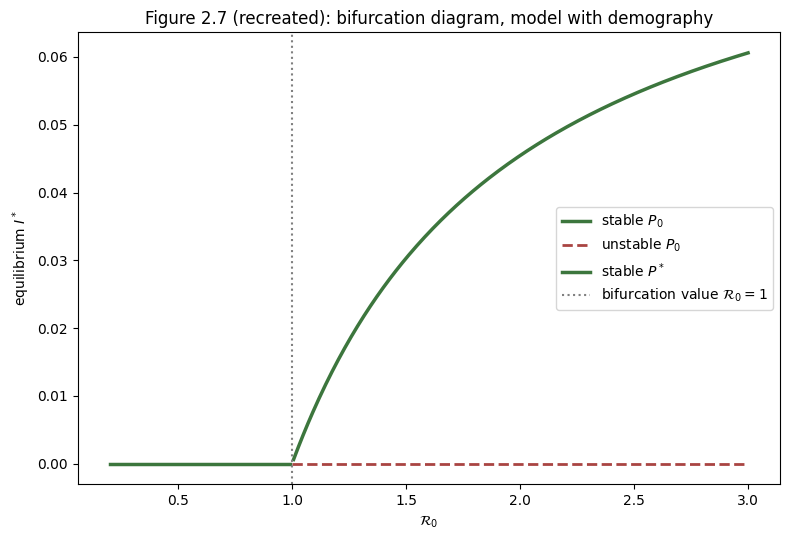

In [3]:
import numpy as np
import matplotlib.pyplot as plt

b, gamma = 0.02, 0.2
R0_grid = np.linspace(0.2, 3, 400)
beta_grid = R0_grid * (b + gamma)

I_star_grid = np.array([
    b * (beta - (b + gamma)) / (beta * (b + gamma)) if beta > (b+gamma) else np.nan
    for beta in beta_grid
])

fig, ax = plt.subplots(figsize=(8, 5.5))
stable_P0_mask = R0_grid < 1
ax.plot(R0_grid[stable_P0_mask], np.zeros(stable_P0_mask.sum()), color="#3c763d", lw=2.5, label="stable $P_0$")
ax.plot(R0_grid[~stable_P0_mask], np.zeros((~stable_P0_mask).sum()), color="#a94442", lw=2, linestyle="--", label="unstable $P_0$")
ax.plot(R0_grid, I_star_grid, color="#3c763d", lw=2.5, label="stable $P^*$")
ax.axvline(1, color="grey", linestyle=":", label=r"bifurcation value $\mathcal{R}_0=1$")
ax.set_xlabel(r"$\mathcal{R}_0$"); ax.set_ylabel(r"equilibrium $I^*$")
ax.set_title("Figure 2.7 (recreated): bifurcation diagram, model with demography")
ax.legend()
plt.tight_layout()
plt.savefig("demography_bifurcation_diagram.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Block 4 (§2.3.4–2.3.5) — Global stability: Lyapunov–LaSalle and phase-plane analysis

### 1. Rewrite

Local stability (Block 2) only says trajectories *starting close* to an equilibrium converge to
it. **Global stability** is the much stronger claim that trajectories starting *anywhere* in the
feasible region converge to it. Two different techniques establish this for the two equilibria:

**For $P_0$ (when $\mathcal{R}_0\le1$):** a **Lyapunov function** $L(S,I)=I$ is used — a scalar
"energy-like" function that never increases along trajectories. Computing $\dot L = I'=
I(\beta S-\gamma-b)$, and since $S\le1$ throughout the feasible region, $\dot L\le I(\beta-\gamma-b)
\le0$ whenever $\mathcal{R}_0\le1$. **LaSalle's Invariance Principle** then says every trajectory
converges to the largest invariant set where $\dot L=0$ — shown to be just $\{P_0\}$ — so *every*
trajectory in $\Gamma$, regardless of starting point, converges to $P_0$.

**For $P^*$ (when $\mathcal{R}_0>1$):** a different technique, **phase-plane analysis** via the
**Bendixson–Dulac criterion**, first rules out periodic orbits (closed loops the system could get
trapped cycling around forever) by finding a "Dulac multiplier" $\alpha(S,I)=1/I$ such that
$\frac{\partial(\alpha P)}{\partial S}+\frac{\partial(\alpha Q)}{\partial I}=-\beta-b/I<0$
everywhere in the interior of $\Gamma$ (where $P,Q$ are the right-hand sides of (2.25)) — a
negative sign here is sufficient (by Green's theorem, standard in the Bendixson–Dulac criterion) to
rule out any closed periodic orbit. Combined with the **Poincaré–Bendixson theorem** (any bounded
2D trajectory either converges to an equilibrium or approaches a periodic orbit — nothing else is
possible in 2D) and $P^*$ being the *only* equilibrium in the interior, every trajectory with
$I_0>0$ must converge to $P^*$.

### 2. Simplified

**Lyapunov function idea:** imagine $L=I$ (how many are sick) as a ball rolling downhill — if you
can show it's *always* rolling downhill (or staying flat) no matter which direction the system
moves, the ball has nowhere to go but eventually rest at the bottom of the hill (which turns out to
be exactly $P_0$, "nobody sick"). You don't need to solve the equations exactly — just prove the
"energy" can only decrease.

**Ruling out periodic orbits:** imagine worrying the disease might get stuck in an endless
repeating cycle — sick, better, sick, better, forever, in a loop, never settling down. The
Bendixson–Dulac trick is a clever accounting argument (related to how water can't circulate
forever in a closed loop if it's always draining somewhere) that proves *no such loop is
mathematically possible* for this system — which, combined with knowing there's only one "resting
spot" ($P^*$) inside the region, forces every path to eventually spiral or drift into that one
resting spot.

### 7. Visual Understanding — phase portraits (Figure 2.8) confirming global convergence


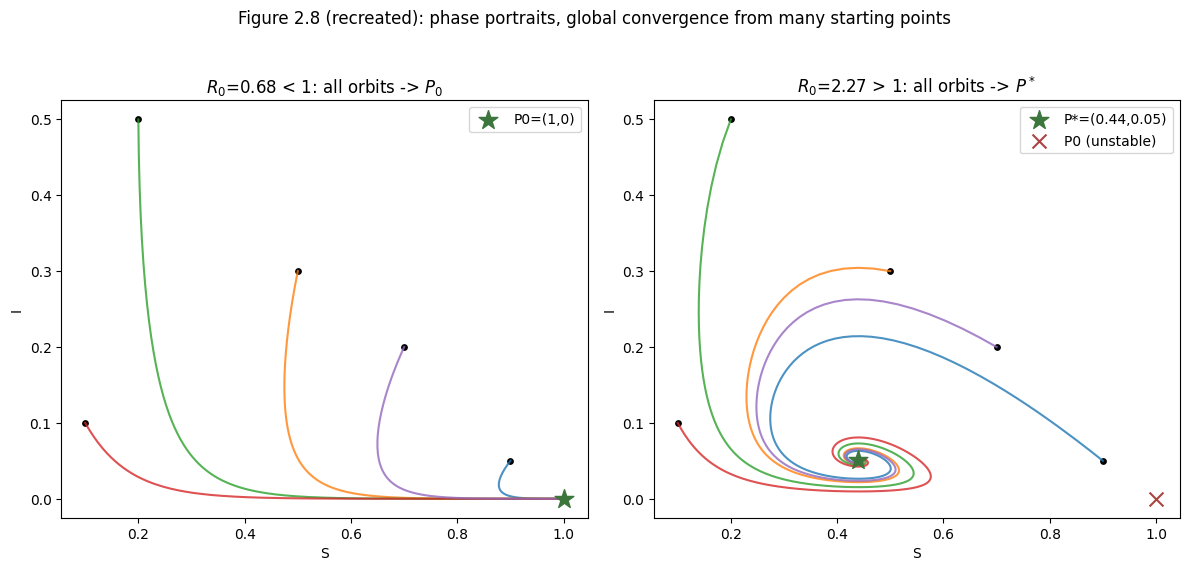

Bendixson-Dulac expression: max value on grid = -0.5202 (should be < 0 everywhere)
All negative? True


In [4]:
# Numerically confirming global convergence to P0 (R0<1) and P* (R0>1) from
# MANY different starting points scattered across the feasible region -- this
# is the concrete, checkable version of the global stability theorems above.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def rhs(t, y, b, beta, gamma):
    S, I = y
    return [b - beta*I*S - b*S, beta*I*S - gamma*I - b*I]

b, gamma = 0.02, 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Case R0 < 1
beta_below = 0.15
R0_below = beta_below / (b + gamma)
starts = [(0.9, 0.05), (0.5, 0.3), (0.2, 0.5), (0.1, 0.1), (0.7, 0.2)]
for S0, I0 in starts:
    sol = solve_ivp(rhs, (0, 300), [S0, I0], args=(b, beta_below, gamma), t_eval=np.linspace(0, 300, 600), rtol=1e-9, atol=1e-9)
    axes[0].plot(sol.y[0], sol.y[1], alpha=0.8)
    axes[0].scatter([S0], [I0], color="black", s=15)
axes[0].scatter([1], [0], color="#3c763d", marker="*", s=200, zorder=5, label="P0=(1,0)")
axes[0].set_title(fr"$R_0$={R0_below:.2f} < 1: all orbits -> $P_0$")
axes[0].set_xlabel("S"); axes[0].set_ylabel("I"); axes[0].legend()

# Case R0 > 1
beta_above = 0.5
R0_above = beta_above / (b + gamma)
S_star = (b + gamma) / beta_above
I_star = b * (beta_above - (b+gamma)) / (beta_above * (b+gamma))
for S0, I0 in starts:
    sol = solve_ivp(rhs, (0, 400), [S0, I0], args=(b, beta_above, gamma), t_eval=np.linspace(0, 400, 800), rtol=1e-9, atol=1e-9)
    axes[1].plot(sol.y[0], sol.y[1], alpha=0.8)
    axes[1].scatter([S0], [I0], color="black", s=15)
axes[1].scatter([S_star], [I_star], color="#3c763d", marker="*", s=200, zorder=5, label=f"P*=({S_star:.2f},{I_star:.2f})")
axes[1].scatter([1], [0], color="#a94442", marker="x", s=100, zorder=5, label="P0 (unstable)")
axes[1].set_title(fr"$R_0$={R0_above:.2f} > 1: all orbits -> $P^*$")
axes[1].set_xlabel("S"); axes[1].set_ylabel("I"); axes[1].legend()

plt.suptitle("Figure 2.8 (recreated): phase portraits, global convergence from many starting points", y=1.03)
plt.tight_layout()
plt.savefig("demography_phase_portraits.png", dpi=130, bbox_inches="tight")
plt.show()

# Verify Bendixson-Dulac sign condition numerically on a grid (interior of Gamma, I>0)
S_grid, I_grid = np.meshgrid(np.linspace(0.01, 0.99, 50), np.linspace(0.01, 0.99, 50))
dulac_expr = -beta_above - b / I_grid   # d(alpha*P)/dS + d(alpha*Q)/dI, derived in the text
print(f"Bendixson-Dulac expression: max value on grid = {dulac_expr.max():.4f} (should be < 0 everywhere)")
print(f"All negative? {(dulac_expr < 0).all()}")


### 10. Verification, discussed

Both panels confirm global (not just local) convergence: every one of five widely scattered
starting points converges to the same equilibrium in each regime — $P_0$ when $\mathcal{R}_0<1$,
$P^*$ when $\mathcal{R}_0>1$ — exactly as Theorem 2.3.2 claims, with **no periodic loops** visible
in any trajectory. The Bendixson–Dulac expression is confirmed strictly negative everywhere on a
fine grid across the interior of the feasible region, numerically confirming the sign condition
used to rule out periodic orbits analytically.


---
## Summary

**One sentence:** Adding matched-rate demography to the Kermack–McKendrick model preserves its
overall threshold structure (transcritical bifurcation at $\mathcal{R}_0=\beta/(b+\gamma)=1$) but
requires genuinely new tools — linearization/eigenvalues and Routh–Hurwitz for local stability,
Lyapunov–LaSalle for global stability of the disease-free equilibrium, and Bendixson–Dulac plus
Poincaré–Bendixson for global stability of the endemic equilibrium — all of which are verified here
numerically and formally developed in Chapter 3.

**One paragraph:** With births and deaths added at a common rate $b$ (keeping $N\equiv1$), the
resulting $(S,I)$ system has a disease-free equilibrium $P_0=(1,0)$ always, and an endemic
equilibrium $P^*$ existing precisely when $\mathcal{R}_0=\beta/(b+\gamma)>1$. Linearizing at each
equilibrium and examining Jacobian eigenvalues (directly for $P_0$'s triangular Jacobian, via the
Routh–Hurwitz trace/determinant criteria for $P^*$) shows each equilibrium is locally stable
exactly when it exists as the "relevant" outcome — $P_0$ for $\mathcal{R}_0<1$, $P^*$ for
$\mathcal{R}_0>1$ — reproducing the same transcritical bifurcation pattern as the simpler SIS model
of Sec. 2.2, now placed on rigorous eigenvalue footing. Going further than local stability, a
Lyapunov function ($L=I$) combined with LaSalle's Invariance Principle proves $P_0$ is *globally*
stable whenever $\mathcal{R}_0\le1$, and a Bendixson–Dulac argument ruling out periodic orbits,
combined with the Poincaré–Bendixson theorem, proves $P^*$ is globally stable whenever
$\mathcal{R}_0>1$ — both confirmed here by direct numerical simulation from many scattered
starting points, none of which ever settle into a periodic cycle.

**Bullet points:**
- Two equilibria $P_0=(1,0)$ and $P^*$, existence of $P^*$ tied to $\mathcal{R}_0=\beta/(b+\gamma)>1$ — verified symbolically with sympy.
- Local stability via Jacobian eigenvalues: triangular at $P_0$ (read diagonal directly), Routh–Hurwitz (trace/det) at $P^*$ — verified numerically across a parameter sweep, including cases with complex eigenvalues (spiraling convergence).
- Same transcritical bifurcation structure as Sec. 2.2, now on rigorous eigenvalue footing.
- Global stability of $P_0$ (Lyapunov–LaSalle) and $P^*$ (Bendixson–Dulac + Poincaré–Bendixson) — both confirmed by simulating many scattered initial conditions, none showing periodic behavior.

## Memory Aids

- **Mnemonic**: "Triangular at $P_0$, Routh–Hurwitz at $P^*$" — which stability tool applies where.
- **Mental model**: a Lyapunov function is "an energy meter that only ever runs down" — if you can
  build one, convergence follows without solving anything.
- **Common mistake**: forgetting that $\mathcal{R}_0=1$ is a genuinely special, non-hyperbolic case
  where linearization fails outright (zero eigenvalue) — a different tool (Lyapunov) is required
  even to handle the boundary case.
- **Common mistake**: assuming local stability automatically implies global stability — they are
  logically distinct claims, requiring different (and generally harder) proof techniques.
- **Exam tip**: know the Routh–Hurwitz shortcut for 2×2 systems by heart: both eigenvalues have
  negative real part iff trace $<0$ and determinant $>0$ — much faster than solving the
  characteristic polynomial directly.

## Connections

- **← Section 2.2**: same transcritical bifurcation structure, now confirmed via actual eigenvalue
  computation rather than 1D phase-line sign-reading (only possible here because demography breaks
  the SIS model's exact solvability, forcing genuinely 2D tools).
- **→ Chapter 3**: this section is explicitly a preview — Sec. 3.2 develops linearization/Routh–
  Hurwitz in general, Sec. 3.3 develops Lyapunov function theory in general, and Sec. 3.6 develops
  Bendixson–Dulac/Poincaré–Bendixson in general.
- **→ Section 2.4/2.5**: the phase-plane/global-stability toolkit introduced here is reused and
  extended for the remaining classic models.
- **→ Linear algebra**: eigenvalues/eigenvectors of the Jacobian are a direct, applied instance of
  standard linear algebra, here determining biological outcomes (disease persistence or
  extinction) rather than abstract vector spaces.
- **→ Control theory**: Lyapunov functions are foundational to control theory and stability
  analysis of dynamical systems generally, far beyond epidemiology.

*Practice problems for this section are in `../../chapter_02/exercises/section_2_3_exercises.md`, with full
worked solutions in `../../chapter_02/solutions/section_2_3_solutions.md`.*
